**IMPORTING + READING FILE + DIVIDING + SCALING**

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler

# --- Load and interpolate ---
# fielPath = os.path.dirname(os.path.abspath(__file__))   
# dataPath = os.path.join(fielPath, "waveData.csv")
dataPath = "waveData.csv"

waveData = pd.read_csv(dataPath)
time = waveData["Time"].to_numpy()
prob = waveData.iloc[:, 1:].to_numpy()

time = np.arange(time[0], time[-1], 0.5)
prob_interp = np.zeros((len(time), prob.shape[1]), dtype=np.float32)
for i in range(prob.shape[1]):
    prob_interp[:, i] = np.interp(time, waveData["Time"], prob[:, i])

# --- Convert to TimeSeries ---
start_time = pd.Timestamp("2025-01-01")
datetime_index = start_time + pd.to_timedelta(time, unit="s")

# Upstream as covariates: columns 0–20
df_covariates = pd.DataFrame(prob_interp[:, :21], index=datetime_index)
df_covariates.index.name = "Time"
past_covariates = TimeSeries.from_dataframe(df_covariates)

# Downstream as target: columns 21+
df_target = pd.DataFrame(prob_interp[:, 21:], index=datetime_index)
df_target.index.name = "Time"
target_series = TimeSeries.from_dataframe(df_target)

# --- Train/Validation split ---
train_target, val_target = target_series.split_after(0.75)
train_cov, val_cov = past_covariates.split_after(0.75)

# --- Scale data ---
scaler_target = Scaler()
scaler_cov = Scaler()

train_target_scaled = scaler_target.fit_transform(train_target)
val_target_scaled = scaler_target.transform(val_target)
full_target_scaled = scaler_target.transform(target_series)

train_cov_scaled = scaler_cov.fit_transform(train_cov)
val_cov_scaled = scaler_cov.transform(val_cov)
full_cov_scaled = scaler_cov.transform(past_covariates)


**CREATE A MODEL**

In [ ]:
m = 240
n = 80
e = 100

from darts.models import TCNModel

model = TCNModel(
    input_chunk_length=m,
    output_chunk_length=n,
    n_epochs=e,
    dropout=0.1,
    kernel_size=5,
    num_filters=3,
    weight_norm=True,
    save_checkpoints=True,
    random_state=42
)

model.fit(series=train_target_scaled, past_covariates=train_cov_scaled, verbose=True)

**BACKTESTING**

In [ ]:
backtest = model.historical_forecasts(series=val_target_scaled,
                                      past_covariates=val_cov_scaled,
                                      forecast_horizon=n,
                                      retrain=False,
)
last_components = full_target_scaled.components[-4:]
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 8), sharex=True)

left = val_target_scaled.time_index[1500]
right = val_target_scaled.time_index[1750]

for i, comp in enumerate(last_components):
    val_target_scaled[comp].plot(label="actual", ax=axes[i])
    backtest[comp].plot(label="forecast", lw=2, ax=axes[i])
    axes[i].set_xlim(left=left, right=right)
    axes[i].set_title(f"Probe: {comp}")

axes[0].legend()

plt.tight_layout()

**BACKTESTING WITH MISSING COVARIATES**

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


/Users/ralkarem/anaconda3/envs/dolEnv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


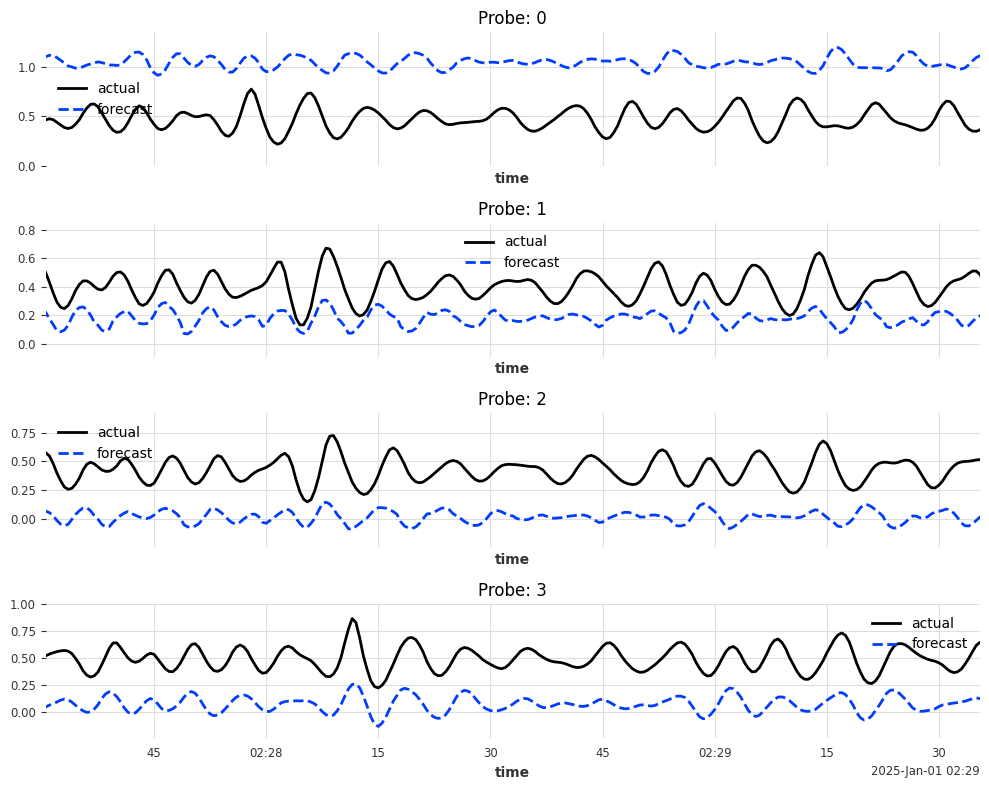

In [101]:

masked_cov = val_cov_scaled.copy() 
masked_tgt = val_target_scaled.copy() 
masked_cov_array = masked_cov.all_values(copy=True)
masked_tgt_array = masked_tgt.all_values(copy=True)

# Index to offline covariate signals
# idx_cov = [0]                                                        # offlining a single probe
idx_cov = list(range(0, 14))                                           # offlining some probes
# idx_cov = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 13, 14, 15, 17, 19, 20]  # replicating lab results
# idx_cov = list(range(21))                                             # zeroing out all probes

# Index to offline target signals
idx_tgt = []
# idx_tgt = [0]                                                        # offlining a single probe
# idx_tgt = [0, 1, 2]                                                  # replicating lab results


masked_cov_array[:, idx_cov, :] = 0.0
masked_tgt_array[:, idx_tgt, :] = 0.0
masked_cov = TimeSeries.from_times_and_values(val_cov_scaled.time_index, masked_cov_array)
masked_tgt = TimeSeries.from_times_and_values(val_target_scaled.time_index, masked_tgt_array)


backtest = model.historical_forecasts(series=masked_tgt,
                                      past_covariates=masked_cov,
                                      forecast_horizon=1*n,
                                      retrain=False,
)
last_components = full_target_scaled.components[-4:]
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 8), sharex=True)

left = val_target_scaled.time_index[1500]
right = val_target_scaled.time_index[1750]

for i, comp in enumerate(last_components):
    val_target_scaled[comp].plot(label="actual", ax=axes[i])
    backtest[comp].plot(label="forecast", lw=2, ax=axes[i], linestyle="--")
    axes[i].set_xlim(left=left, right=right)
    axes[i].set_title(f"Probe: {comp}")

axes[0].legend()

plt.tight_layout()

**SAVE A MODEL**    


In [ ]:
model.save(f"tcn_C21_m_{m}_n{n}_e{e}", "model")

**LOAD A MODEL**

In [ ]:
modelName = f"tcn_C21_m_{m}_n{n}_e{e}"
model.load(modelName)